# ***EDA perform on dataset***

Import Libraries

In [24]:
# Import Libraries 
import pandas as pd 
import numpy as  np 
import seaborn as sns
import matplotlib.pyplot as plt 

Load Dataset

In [25]:
# Load dataset

df = pd.read_csv('../dataset/raw/Housing.csv')
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


# **Start EDA**

Step1. Show dataset detail

In [26]:
# show dataset shape
print(df.shape) 
print('-'*200)


# Check missing value
print('Missing Value:\n',df.isnull().sum())
print('-'*200)

# show Duplicate
print('Duplicated value: \n',df.duplicated().sum()) 
print('-'*200)

(545, 13)
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Missing Value:
 price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Duplicated value: 
 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [27]:
# dataset Information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


Step2. Identify the target columns

In [28]:
# Our Goal is to predict the prize. Target Column is Prize

Step3. Visualize the target Column

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


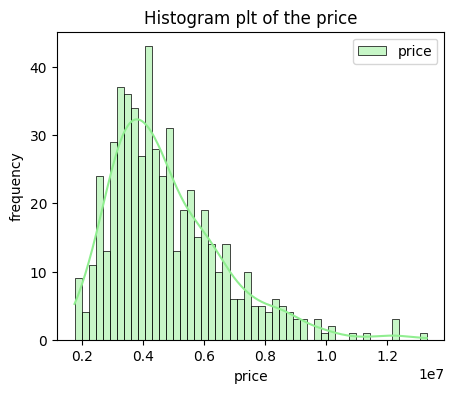

In [29]:
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize=(5,4))
print(df.columns)
sns.histplot(df['price'], kde = True, color='lightgreen', bins=50, label='price')
plt.xlabel('price')
plt.ylabel('frequency')
plt.title(f"Histogram plt of the {'price'}")
plt.legend()
plt.show()

# # It is a right skewed 
# Now Apply Log Normal Distribution function

Draw Log Normal Distribution curve of price

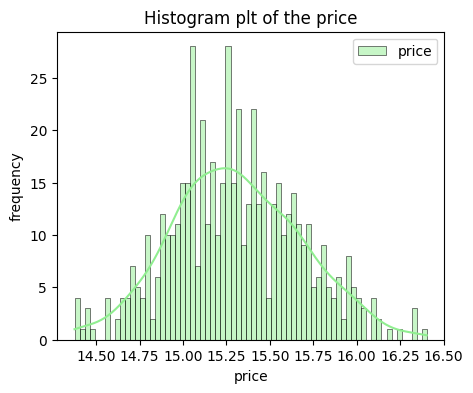

In [33]:
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

# Convert the right skewed prize column into a Normal Distribution curve
df['price'] = np.log1p(df['price'])

plt.figure(figsize=(5,4))
sns.histplot(price, label="price", bins=70, kde=True, color='lightgreen')
plt.xlabel("price")
plt.ylabel("frequency")
plt.title(f"Histogram plt of the {'price'}")
plt.legend()

In [35]:
# -----------------------------------------------------------------------------
# =================== || Filtered Numerical and Categorical Column || =====================
# -----------------------------------------------------------------------------
numerical_feature = df.select_dtypes("int64")
categorical_feature = df.select_dtypes("object")

print('Numerical features: ', numerical_feature.columns)

print('Categorical Feature: ', categorical_feature.columns)

Numerical features:  Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')
Categorical Feature:  Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


Step4. Coorelation Analysis

In [36]:
# -----------------------------------------------------------------------------
# =================== || COORELATION MATRIX || =====================
# -----------------------------------------------------------------------------
correlationMatrix = df.select_dtypes(include='number').corr()

print(correlationMatrix)

# In the below table there is no extremely low correlated column. All are affecting the prize so no need to remove.

              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.543233  0.369986   0.485715  0.415281  0.371638
area       0.543233  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.369986  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.485715  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.415281  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.371638  0.352980  0.139270   0.177496  0.045547  1.000000


Step5. Feature column analysis

In [37]:
# -----------------------------------------------------------------------------
# =================== || CATEGORICAL COLUMNS ANALYSIS || =====================
# -----------------------------------------------------------------------------

categorical_feature = df.select_dtypes("object")

for col in categorical_feature.columns:
    means = df.groupby(col)['price'].mean() 
    print(f'{col}: ',means )
    print('difference: ',means.max()- means.min())
    print('-')

# -----------------------------------------------------------------------------
# difference:
# Difference	Interpretation
# > 0.30	Strong feature
# 0.15 - 0.30	Moderate
# < 0.15	Weak

# ------------------------------------------------------------------------------
# so we are removing the hotwaterheating columns
# ------------------------------------------------------------------------------

mainroad:  mainroad
no     15.004448
yes    15.356764
Name: price, dtype: float64
difference:  0.35231639709597573
-
guestroom:  guestroom
no     15.259054
yes    15.528370
Name: price, dtype: float64
difference:  0.26931573275613196
-
basement:  basement
no     15.247338
yes    15.417542
Name: price, dtype: float64
difference:  0.17020409412752358
-
hotwaterheating:  hotwaterheating
no     15.299734
yes    15.457857
Name: price, dtype: float64
difference:  0.1581237342915749
-
airconditioning:  airconditioning
no     15.192063
yes    15.556211
Name: price, dtype: float64
difference:  0.36414817591928994
-
prefarea:  prefarea
no     15.236831
yes    15.535541
Name: price, dtype: float64
difference:  0.2987100441017674
-
furnishingstatus:  furnishingstatus
furnished         15.450529
semi-furnished    15.359890
unfurnished       15.126622
Name: price, dtype: float64
difference:  0.3239070488886746
-
